In [414]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/")

from sklearn.metrics import roc_curve, roc_auc_score

RENAME     = {'cposedm': 'ocedm'}
RENAME_INV = {v: k for k, v in RENAME.items()}

ZHOU_SCORES = {
    'length': 0.8741, 'edm': 0.9736, 'fsd': 0.9271,
    'coverage': 0.9638, 'ends': 0.9639, 'ocf': 0.9467,
    'ifs': 0.9653, 'wps': 0.9658, 'pfe': 0.9579, 'fsr': 0.9441
}

FEATURE_NAMES = ['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf',
                 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm']


def load_roc_data(directory, feature_names=None, suffix='_probs.csv'):
    if feature_names is None:
        feature_names = FEATURE_NAMES
    roc_data, missing = [], []
    for feature in feature_names:
        path = os.path.join(directory, f"{feature}{suffix}")
        if not os.path.exists(path):
            missing.append(feature)
            continue
        df = pd.read_csv(path)[['probability', 'label']]
        fpr, tpr, _ = roc_curve(df['label'], df['probability'])
        auc = roc_auc_score(df['label'], df['probability'])
        roc_data.append({'name': RENAME.get(feature, feature), 'fpr': fpr, 'tpr': tpr, 'auc': auc})
    roc_data.sort(key=lambda x: x['auc'], reverse=True)
    if missing:
        print(f"Missing: {missing}")
    return roc_data


def plot_roc(roc_data, title, save_path):
    plt.figure(figsize=(8, 7))
    sns.set_theme(style="whitegrid")
    for d in roc_data:
        plt.plot(d['fpr'], d['tpr'], label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def plot_auc_bars(roc_data, title, save_path, zhou_ref=None):
    names = [d['name'] for d in roc_data]
    aucs  = [d['auc']  for d in roc_data]
    fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
    sns.set_theme(style="whitegrid")
    ax.barh(range(len(names)), aucs, color='steelblue', height=0.6)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel('AUC')
    ax.set_title(title)
    if zhou_ref:
        for i, name in enumerate(names):
            z = zhou_ref.get(RENAME_INV.get(name, name))
            if z is not None:
                ax.plot(z, i, 'r|', markersize=14, markeredgewidth=2.5,
                        label='Zhou et al.' if i == 0 else '')
        ax.legend(loc='lower right')
    for i, auc in enumerate(aucs):
        ax.text(auc + 0.003, i, f'{auc:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [415]:
results_folder = "data/model_results/"
rbf_mapq0 = pd.read_csv(results_folder + "svm_rbf_cv1_cv_results.csv")
rbf_mapq15 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq15_cv_results.csv")
rbf_mapq30 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq30_cv_results.csv")
rbf_mapq45 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq45_cv_results.csv")
zhou_scores = pd.DataFrame({
    'length': 0.8741, 'edm': 0.9736, 'fsd': 0.9271,
    'coverage': 0.9638, 'ends': 0.9639, 'ocf': 0.9467,
    'ifs': 0.9653, 'wps': 0.9658, 'pfe': 0.9579, 'fsr': 0.9441
}, index=[0]).T.rename(columns={0: 'auc'})
zhou_scores.index.name = 'feature'


In [416]:
features = pd.DataFrame(FEATURE_NAMES, columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(rbf_mapq0[['feature', 'auc']].rename(columns={'auc': 'mapq0'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq15[['feature', 'auc']].rename(columns={'auc': 'mapq15'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq30[['feature', 'auc']].rename(columns={'auc': 'mapq30'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq45[['feature', 'auc']].rename(columns={'auc': 'mapq45'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,mapq0,mapq15,mapq30,mapq45,zhou
0,length,0.838868,0.831768,0.827131,0.818276,0.8741
1,fsd,0.919653,0.882457,0.881885,0.878259,0.9271
2,fsr,0.713310,0.709855,NaN,NaN,0.9441
3,pfe,0.861493,0.867858,0.866388,0.864060,0.9579
4,coverage,0.776528,0.759676,0.773455,0.763350,0.9638
5,ends,0.798695,0.796805,0.785832,0.792673,0.9639
6,ocf,0.836921,0.830404,0.819382,0.813428,0.9467
7,ifs,0.813485,0.803943,0.810355,0.805689,0.9653
8,wps,0.775373,0.779324,0.777205,0.775955,0.9658
9,edm,0.962556,0.967928,0.968892,0.966468,0.9736


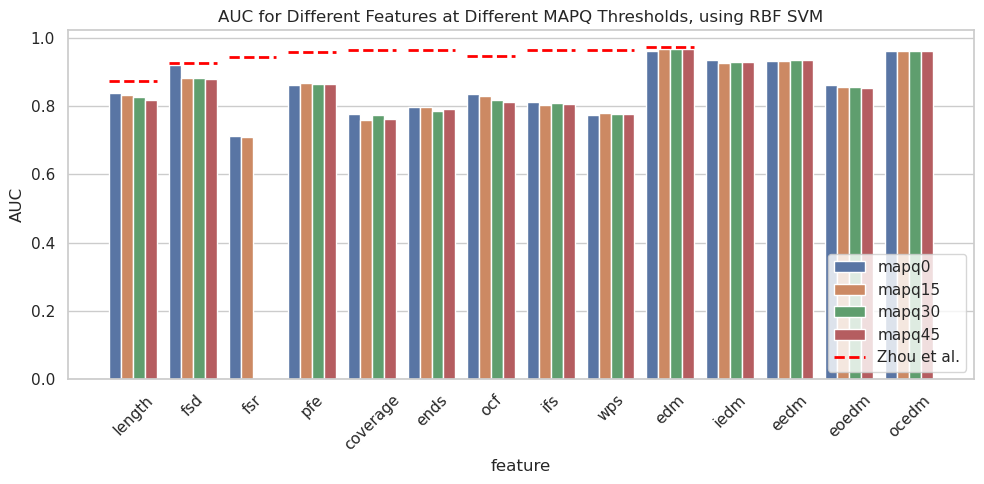

In [417]:
# bar plot of AUC distributions for different MAPQ thresholds
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['mapq0', 'mapq15', 'mapq30', 'mapq45'], var_name='mapq', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('AUC for Different Features at Different MAPQ Thresholds, using RBF SVM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/01_mapq.png")

In [418]:
linear_mapq30 = pd.read_csv(results_folder + "svm_linear_cv1_mapq30_cv_results.csv")
rbf_mapq30 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(rbf_mapq30[['feature', 'auc']].rename(columns={'auc': 'rbf'}), on='feature', how='left')
auc_df = auc_df.merge(linear_mapq30[['feature', 'auc']].rename(columns={'auc': 'linear'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')

# auc_df

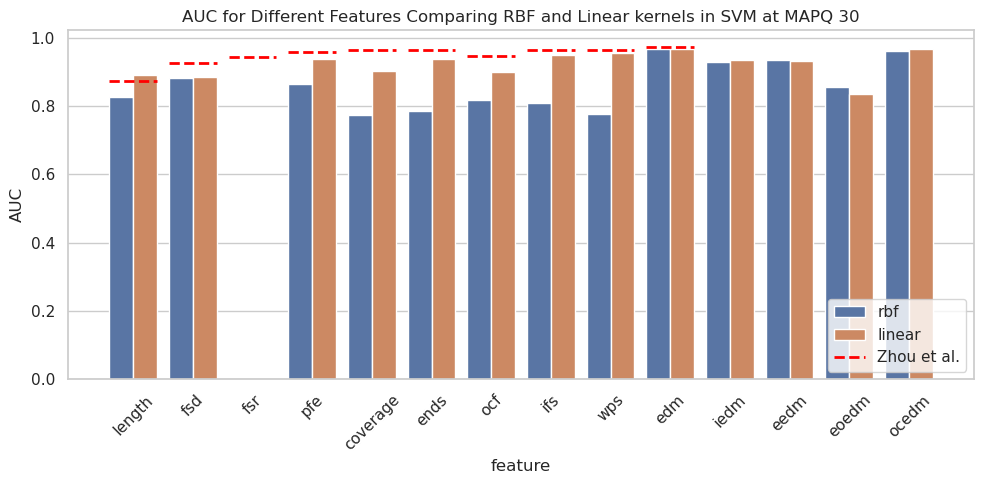

In [419]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['rbf', 'linear'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('AUC for Different Features Comparing RBF and Linear kernels in SVM at MAPQ 30')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/02_kernel.png")

## PCA

In [420]:
linear_no_pca_mapq30 = pd.read_csv(results_folder + "svm_linear_cv1_mapq30_cv_results.csv")
linear_pca50_mapq30 = pd.read_csv(results_folder + "svm_linear_pca50.0_cv1_mapq30_cv_results.csv")
linear_pca100_mapq30 = pd.read_csv(results_folder + "svm_linear_pca100.0_cv1_mapq30_cv_results.csv")
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_cv1_mapq30_cv_results.csv")
linear_pca200_mapq30 = pd.read_csv(results_folder + "svm_linear_pca200.0_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca50_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca50'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca100_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca100'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca150'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca200_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca200'}), on='feature', how='left')
auc_df = auc_df.merge(linear_no_pca_mapq30[['feature', 'auc']].rename(columns={'auc': 'no_pca'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,pca50,pca100,pca150,pca200,no_pca,zhou
0,length,0.873907,0.902554,0.899786,0.890187,0.891093,0.8741
1,fsd,0.876503,0.885368,0.870739,0.867075,0.886618,0.9271
2,fsr,0.412229,NaN,0.743254,NaN,NaN,0.9441
3,pfe,0.914367,0.930904,0.950666,0.931104,0.936811,0.9579
4,coverage,0.323257,0.627810,0.947565,0.945017,0.903164,0.9638
5,ends,0.227127,0.801977,0.946467,0.951115,0.937650,0.9639
6,ocf,0.382801,0.432459,0.902763,0.934091,0.900884,0.9467
7,ifs,0.291462,0.836883,0.952632,0.955676,0.950971,0.9653
8,wps,0.270449,0.638479,0.942259,0.949177,0.955895,0.9658
9,edm,0.950323,0.953529,0.958348,0.961487,0.967442,0.9736


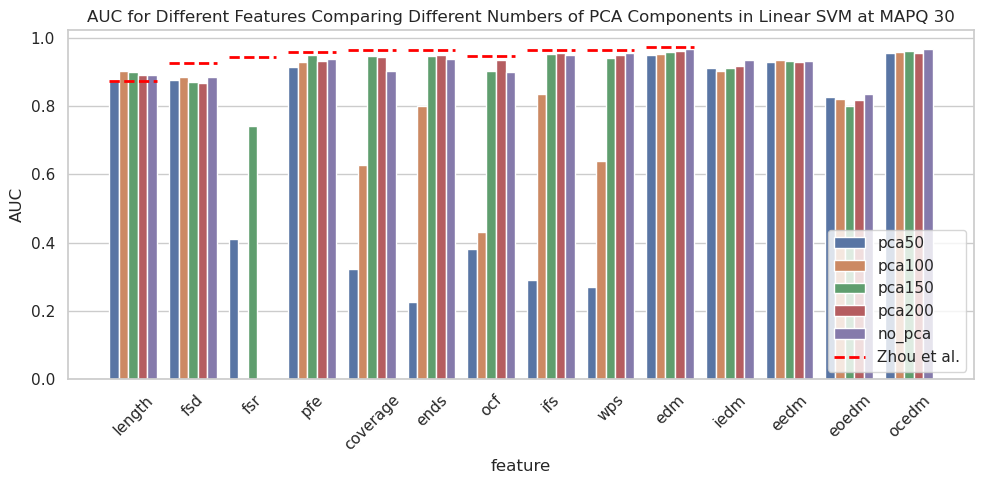

In [421]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['pca50', 'pca100', 'pca150', 'pca200', 'no_pca'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('AUC for Different Features Comparing Different Numbers of PCA Components in Linear SVM at MAPQ 30')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/03_pca.png")

## GC Correction

In [422]:
linear_pca150_mapq30    = pd.read_csv(results_folder + "svm_linear_pca150.0_cv1_mapq30_cv_results.csv")
linear_pca150_gc_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_gc_cv1_mapq30_cv_results.csv")

auc_df = pd.DataFrame(FEATURE_NAMES, columns=['feature'])
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_false'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_gc_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_true'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,gc_false,gc_true,zhou
0,length,0.899786,0.899786,0.8741
1,fsd,0.870739,0.870739,0.9271
2,fsr,0.743254,0.743254,0.9441
3,pfe,0.950666,0.950198,0.9579
4,coverage,0.947565,0.915951,0.9638
5,ends,0.946467,0.939034,0.9639
6,ocf,0.902763,0.914291,0.9467
7,ifs,0.952632,0.940427,0.9653
8,wps,0.942259,0.955533,0.9658
9,edm,0.958348,0.958348,0.9736


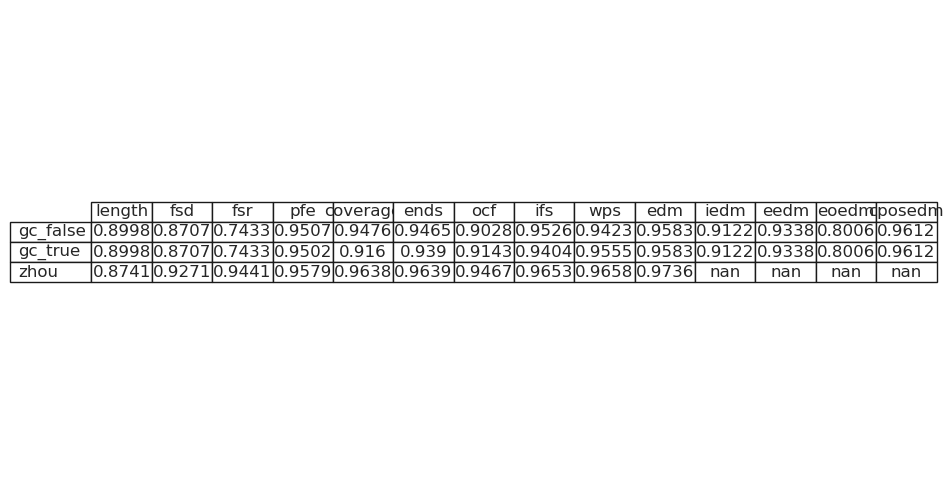

In [423]:
fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')
table_data = auc_df[['feature', 'gc_false', 'gc_true', 'zhou']].round(4).T
col_labels = table_data.iloc[0].tolist()  # feature names as column headers
table_data = table_data.iloc[1:]          # drop the feature row
table = ax.table(
    cellText=table_data.values,
    colLabels=col_labels,
    rowLabels=table_data.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction_table.png", facecolor='white')
plt.show()


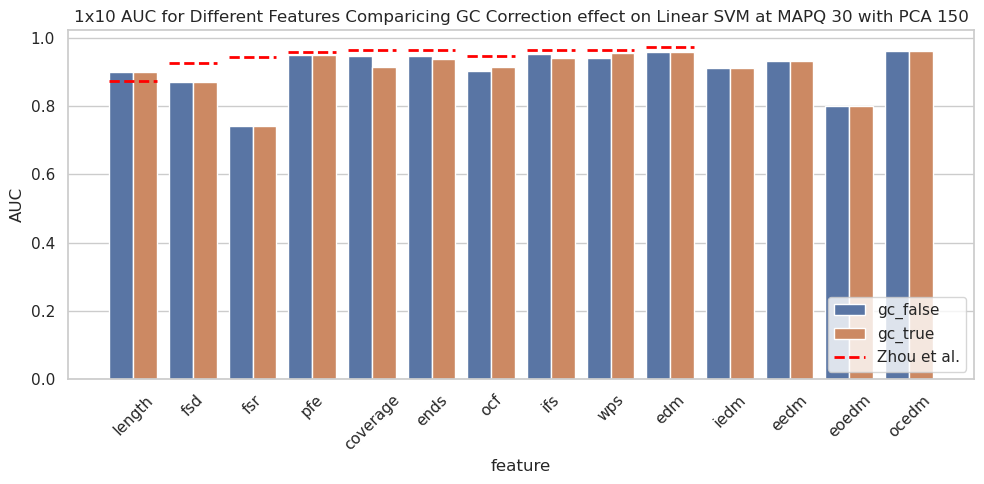

In [424]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(
    id_vars='feature',
    value_vars=['gc_false', 'gc_true'],
    var_name='Model',
    value_name='AUC'
)
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('1x10 AUC for Different Features Comparicing GC Correction effect on Linear SVM at MAPQ 30 with PCA 150')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction.png")

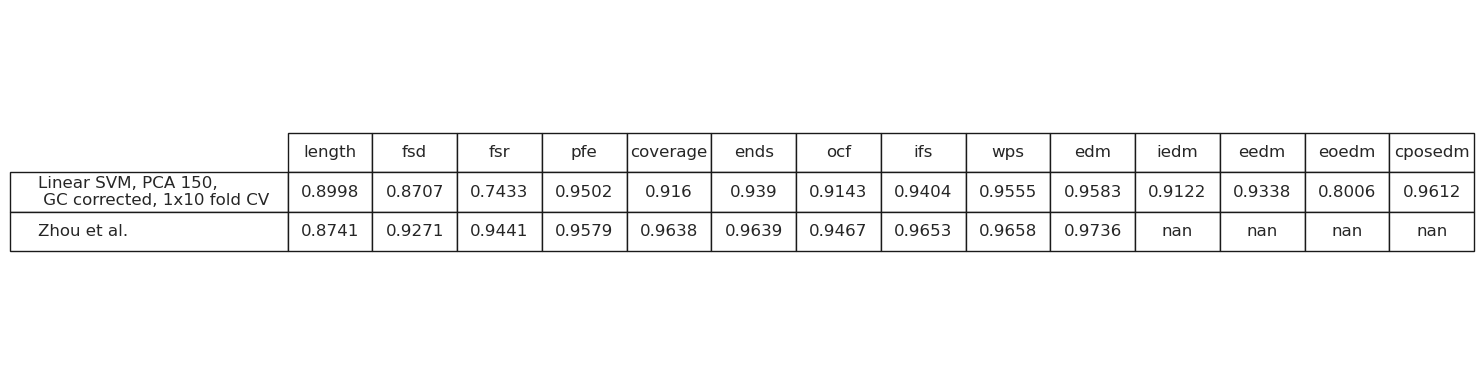

In [425]:
auc_tab = auc_df.set_index('feature')[['gc_true', 'zhou']].round(4).rename(columns={'gc_true': 'Linear SVM, PCA 150,\n GC corrected, 1x10 fold CV', 'zhou': 'Zhou et al.'}).T
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis('off')
table = ax.table(
    cellText=auc_tab.values,
    colLabels=auc_tab.columns,
    rowLabels=auc_tab.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction_table.png", facecolor='white') 

<Figure size 640x480 with 0 Axes>

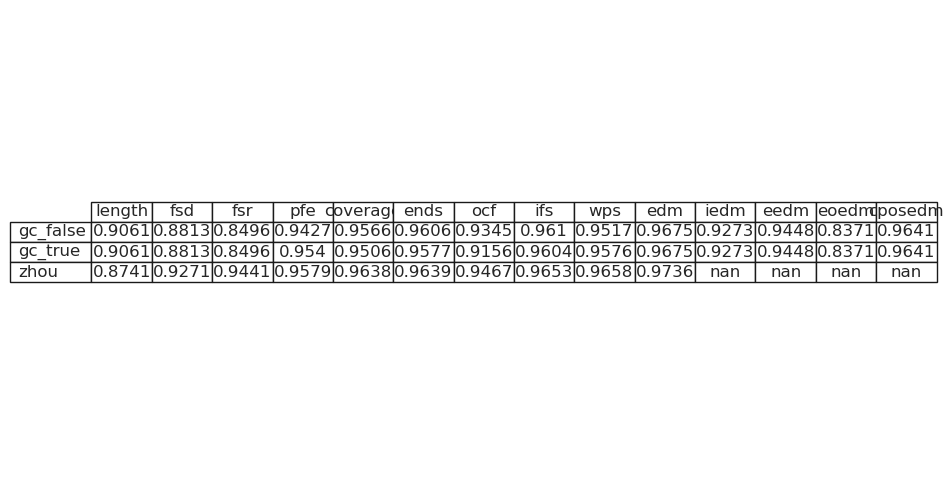

In [426]:
# 10 x 10 cv results for all features, linear kernel, mapq30, pca150, gc correction true vs false
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_mapq30_cv_results.csv")
linear_pca150_gc_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_gc_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_false'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_gc_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_true'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df
plt.figure()
auc_tab = auc_df.T
fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')
table_data = auc_df[['feature', 'gc_false', 'gc_true', 'zhou']].round(4).T
col_labels = table_data.iloc[0].tolist()  # feature names as column headers
table_data = table_data.iloc[1:]          # drop the feature row
table = ax.table(
    cellText=table_data.values,
    colLabels=col_labels,
    rowLabels=table_data.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("scripts/analysis/05_gc_cv10_table.png", facecolor='white')
plt.show()


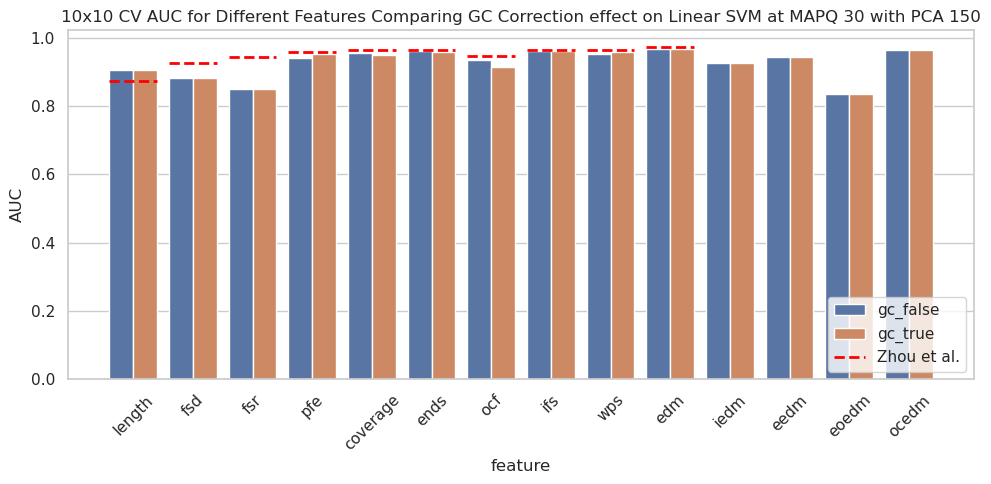

In [427]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(
    id_vars='feature',
    value_vars=['gc_false', 'gc_true'],
    var_name='Model',
    value_name='AUC'
)
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('10x10 CV AUC for Different Features Comparing GC Correction effect on Linear SVM at MAPQ 30 with PCA 150')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/05_gc_cv10.png")

## TODO

- ROC curves — full curves for CV and external test sets (best config), no CI
- Score distributions — violin/box plots of predicted probability, cancer vs healthy, per feature
- Feature correlation heatmap — correlation of predicted probabilities across features (motivates ensemble)
- Stage-stratified AUC — Cristiano stage I/II/III/IV; use stage info from manifest
- Cross-dataset heatmap — feature × dataset AUC matrix (Cristiano/CRC train × LY/GeoScan test), once external validation complete

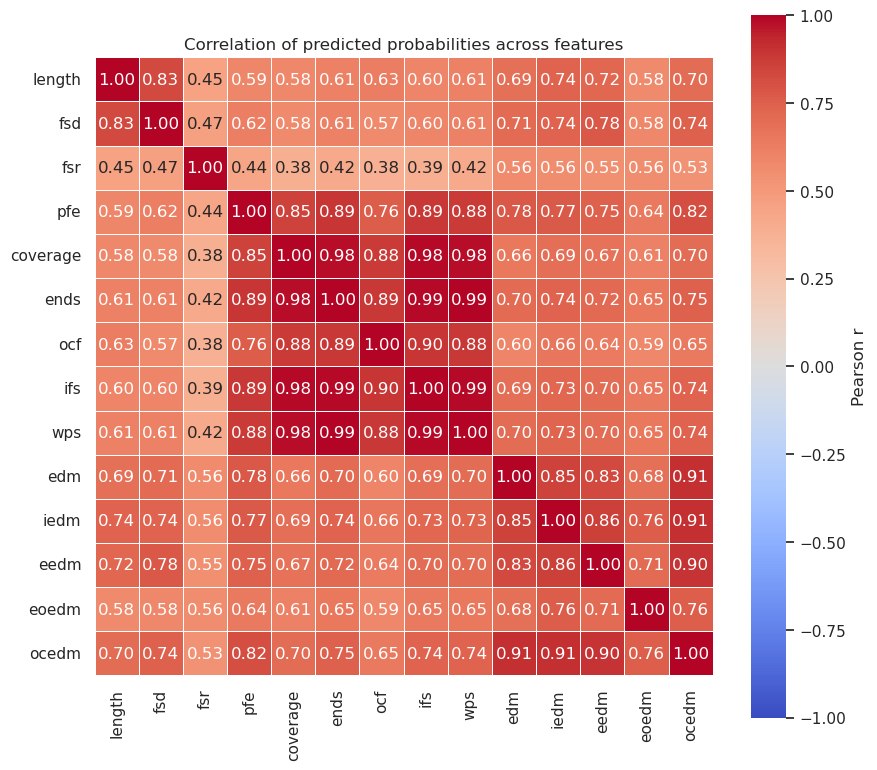

In [428]:
cv_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
feature_names = ['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm']

probs_wide = None
for feature in feature_names:
    df = pd.read_csv(cv_dir + f"{feature}_cv_probs.csv")[['sample_id', 'probability']].rename(columns={'probability': feature})
    probs_wide = df if probs_wide is None else probs_wide.merge(df, on='sample_id')

corr = probs_wide.drop(columns='sample_id').corr()
plot_corr = corr.rename(index=RENAME, columns=RENAME)

plt.figure(figsize=(9, 8))
sns.set_theme(style="white")
sns.heatmap(plot_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of predicted probabilities across features')
plt.tight_layout()
plt.savefig("scripts/analysis/07_feature_corr.png")

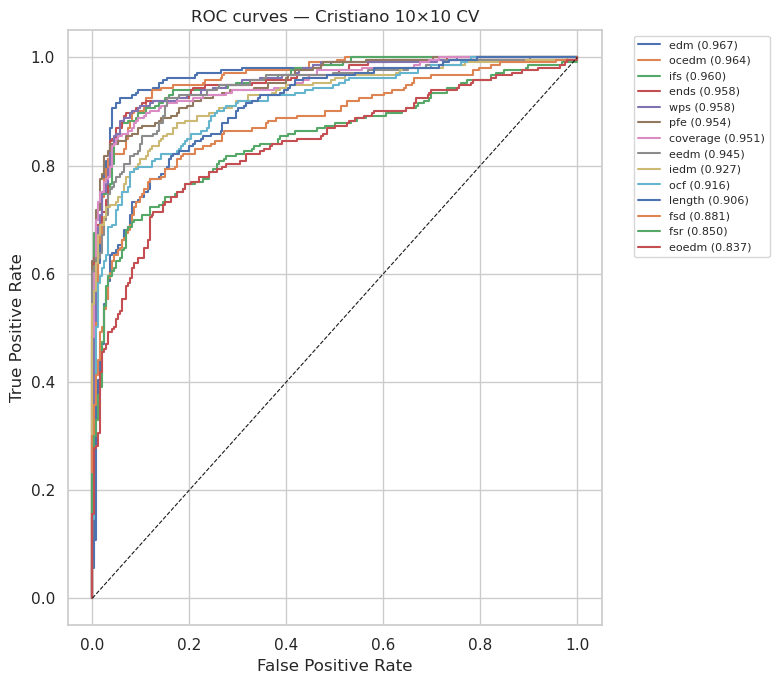

In [429]:
cv_roc = load_roc_data("data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/", suffix='_cv_probs.csv')
plot_roc(cv_roc, 'ROC curves — Cristiano 10×10 CV', 'scripts/analysis/08_roc_cv.png')

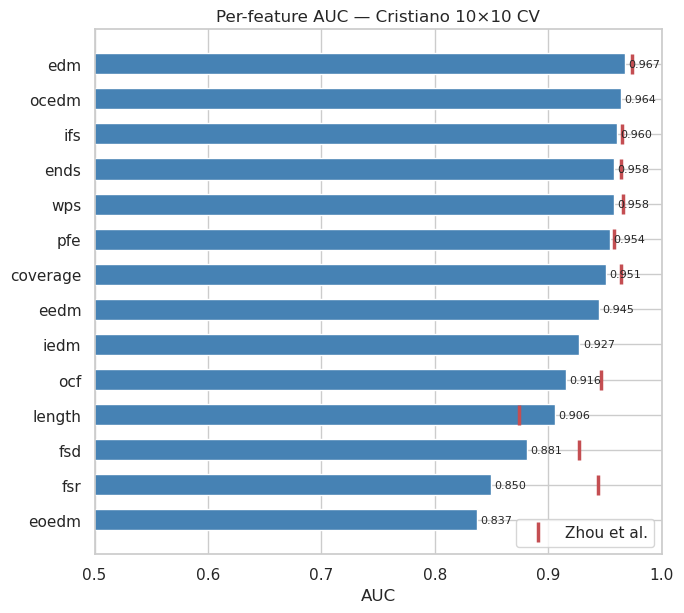

In [430]:
plot_auc_bars(cv_roc, 'Per-feature AUC — Cristiano 10×10 CV', 'scripts/analysis/09_auc_bars_cv.png', zhou_ref=ZHOU_SCORES)

In [431]:
# TODO: Ensemble external validation
# For each training config (Cristiano, CRC, LY): run ensemble predictions on LY + GS test sets
# Prerequisites: per-feature test probs complete + ensemble models trained
# Plots:
#   - ROC: each ensemble vs best per-feature on LY test
#   - AUC bar: Cristiano ensemble vs CRC ensemble vs LY ensemble on LY test

In [432]:
# TODO: Cross-dataset summary heatmap
# Rows: features; Columns: Cristiano CV, CRC CV, Cristiano→LY, CRC→LY, LY→LY, Cristiano→GS, CRC→GS
# Single figure summarising all transfer conditions — main external validation figure
# Blocked until all test jobs complete

Missing: ['fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']


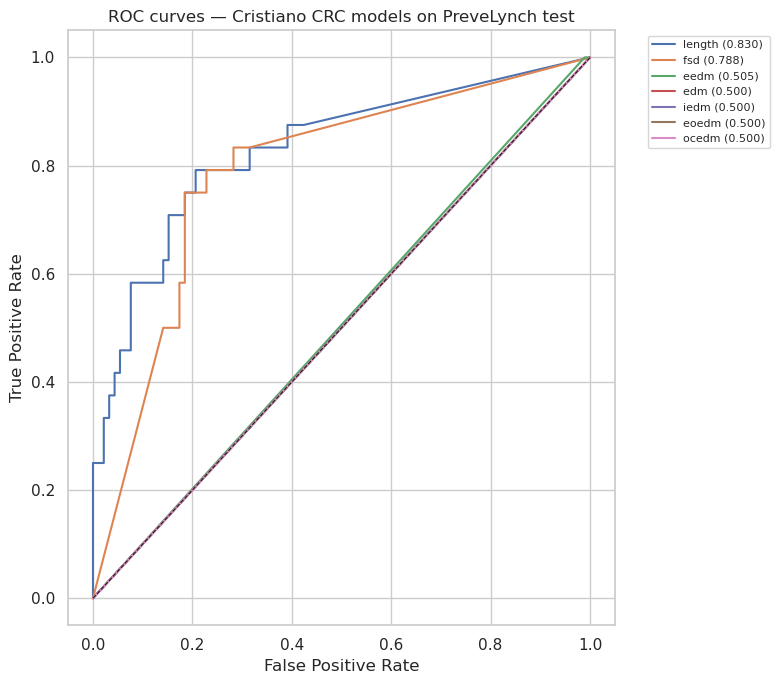

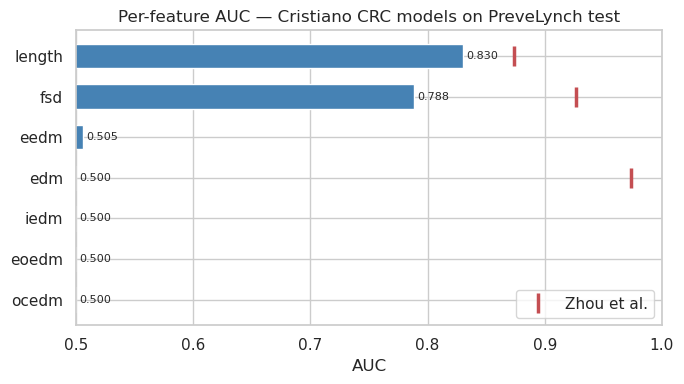

Missing: ['fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']


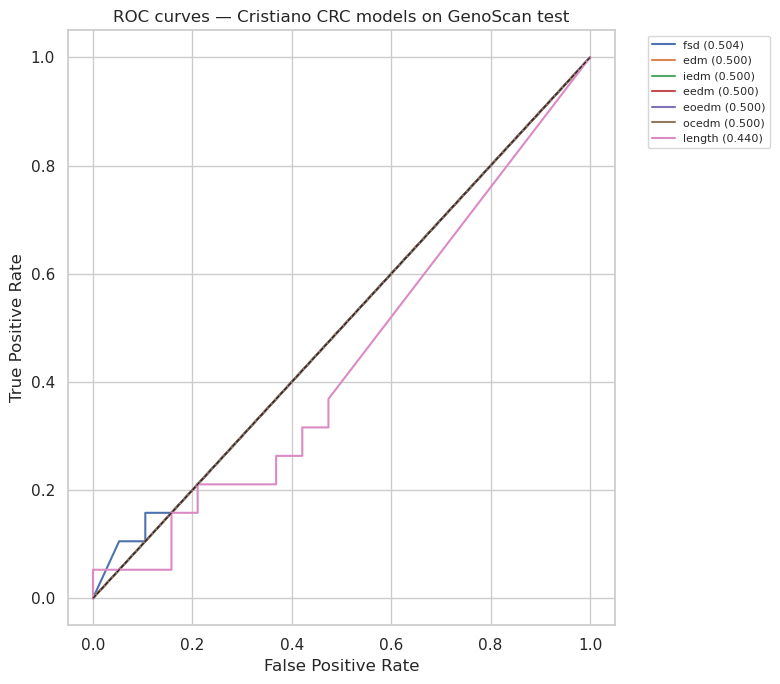

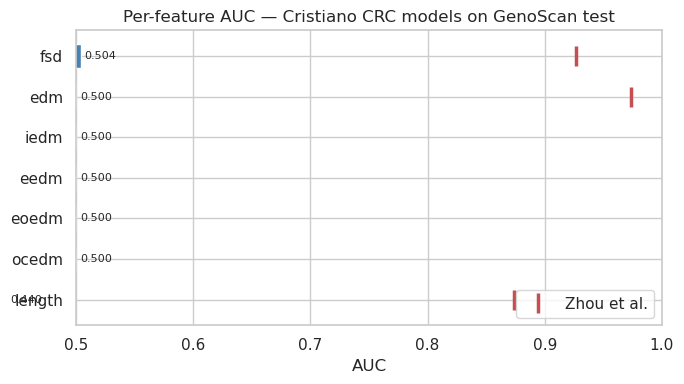

In [433]:
# CRC models → LY test + GS test
crc_ly_dir = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
crc_gs_dir = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"

crc_ly_roc = load_roc_data(crc_ly_dir)
plot_roc(crc_ly_roc, 'ROC curves — Cristiano CRC models on PreveLynch test', 'scripts/analysis/14_roc_crc_ly.png')
plot_auc_bars(crc_ly_roc, 'Per-feature AUC — Cristiano CRC models on PreveLynch test', 'scripts/analysis/15_auc_crc_ly.png', zhou_ref=ZHOU_SCORES)

crc_gs_roc = load_roc_data(crc_gs_dir)
plot_roc(crc_gs_roc, 'ROC curves — Cristiano CRC models on GenoScan test', 'scripts/analysis/16_roc_crc_gs.png')
plot_auc_bars(crc_gs_roc, 'Per-feature AUC — Cristiano CRC models on GenoScan test', 'scripts/analysis/17_auc_crc_gs.png', zhou_ref=ZHOU_SCORES)

Missing: ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']


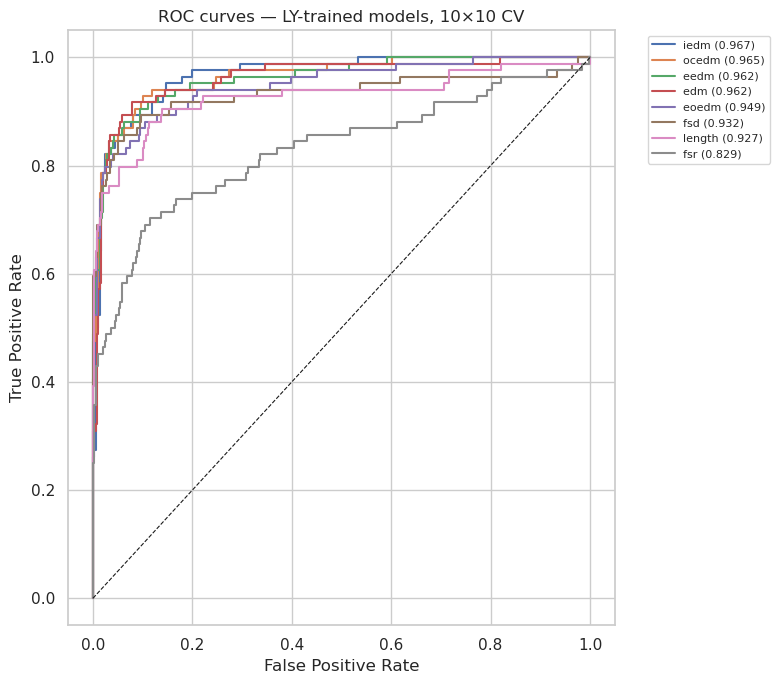

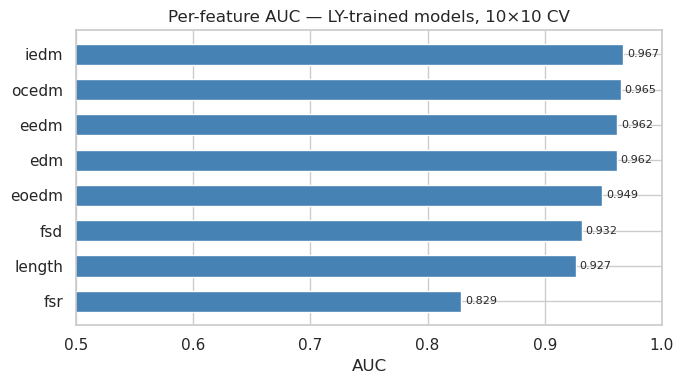

In [434]:
# ly trained models 10x10 cv results roc + auc
ly_cv_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
ly_cv_roc = load_roc_data(ly_cv_dir, suffix='_cv_probs.csv')
plot_roc(ly_cv_roc, 'ROC curves — LY-trained models, 10×10 CV', 'scripts/analysis/18_roc_ly_cv.png')
plot_auc_bars(ly_cv_roc, 'Per-feature AUC — LY-trained models, 10×10 CV', 'scripts/analysis/19_auc_ly_cv.png')

Missing: ['fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']


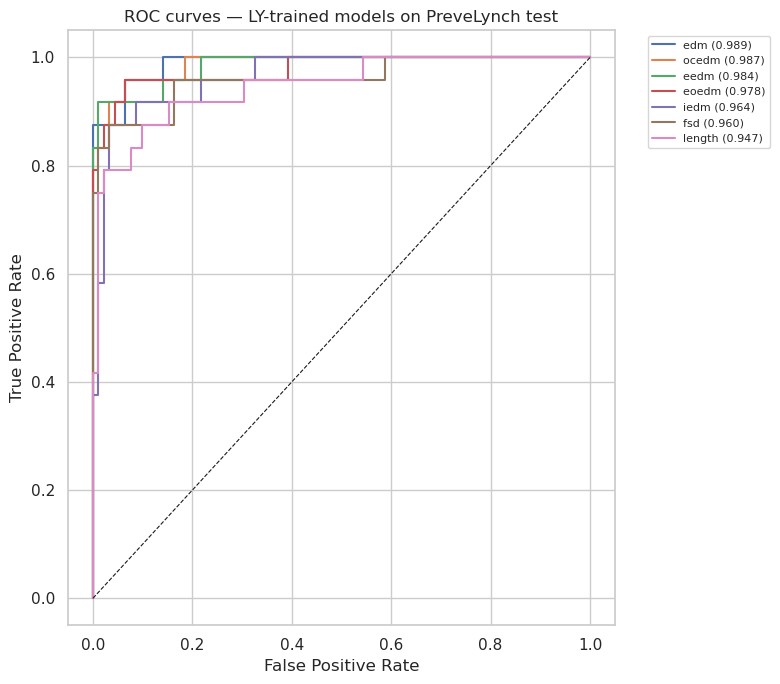

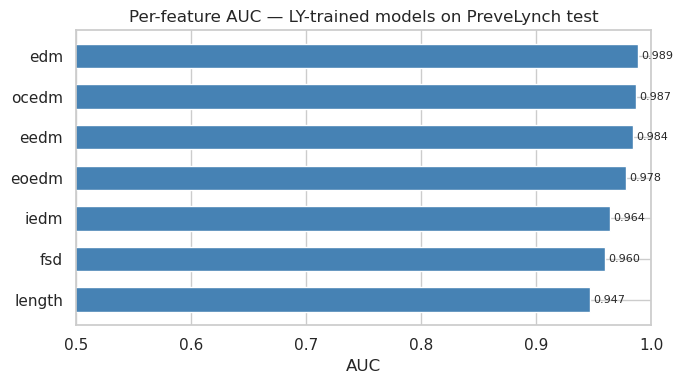

Missing: ['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm']


/tmp/ipykernel_2935546/744391876.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)


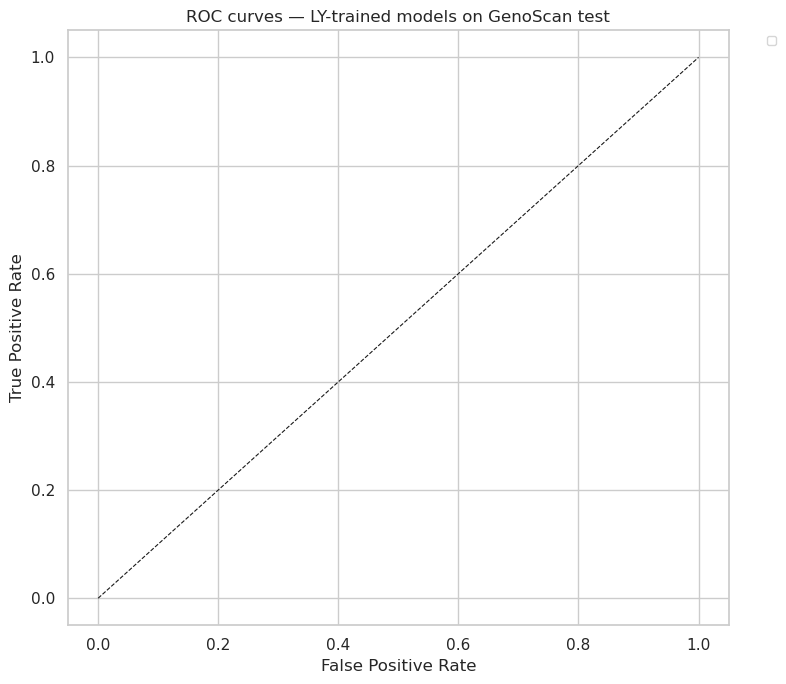

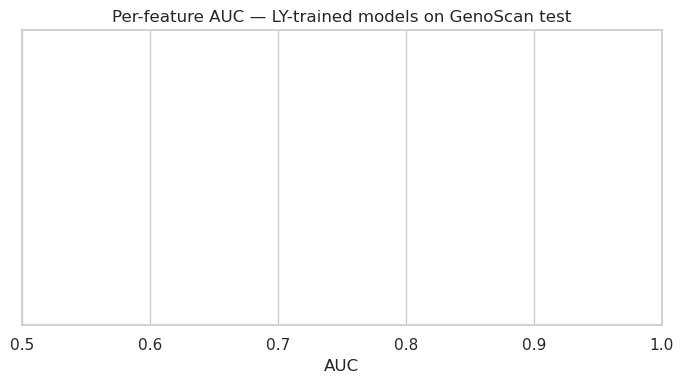

In [435]:
# LY-trained models on LY test
ly_train_ly_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"

ly_ly_roc = load_roc_data(ly_train_ly_dir)
plot_roc(ly_ly_roc, 'ROC curves — LY-trained models on PreveLynch test', 'scripts/analysis/18_roc_ly_ly.png')
plot_auc_bars(ly_ly_roc, 'Per-feature AUC — LY-trained models on PreveLynch test', 'scripts/analysis/19_auc_ly_ly.png')

ly_gs_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"
ly_gs_roc = load_roc_data(ly_gs_dir)
plot_roc(ly_gs_roc, 'ROC curves — LY-trained models on GenoScan test', 'scripts/analysis/20_roc_ly_gs.png')
plot_auc_bars(ly_gs_roc, 'Per-feature AUC — LY-trained models on GenoScan test', 'scripts/analysis/21_auc_ly_gs.png')

Missing: ['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm']


/tmp/ipykernel_2935546/744391876.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)


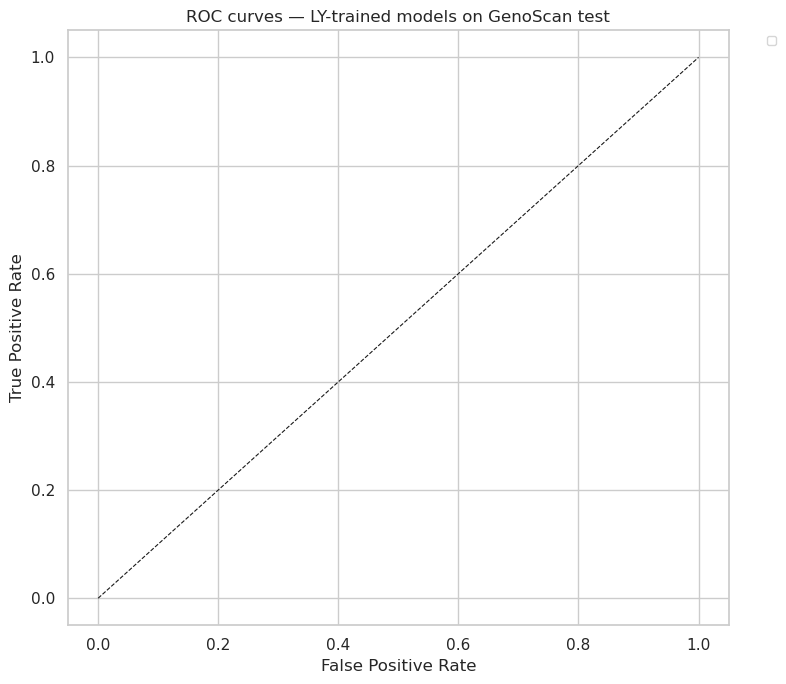

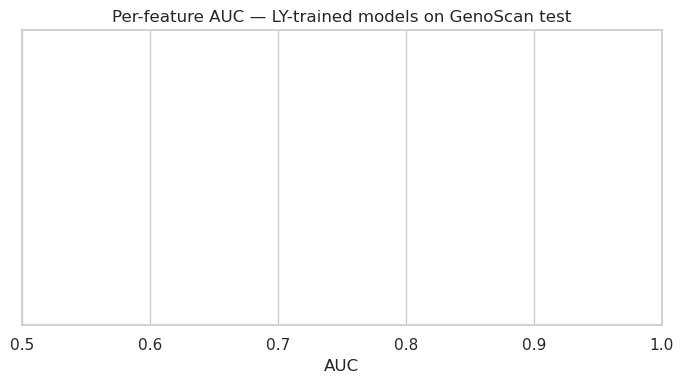

In [436]:
# ly trained models on gs test
ly_gs_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"
ly_gs_roc = load_roc_data(ly_gs_dir)
plot_roc(ly_gs_roc, 'ROC curves — LY-trained models on GenoScan test', 'scripts/analysis/20_roc_ly_gs.png')
plot_auc_bars(ly_gs_roc, 'Per-feature AUC — LY-trained models on GenoScan test', 'scripts/analysis/21_auc_ly_gs.png')

Missing: ['fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']


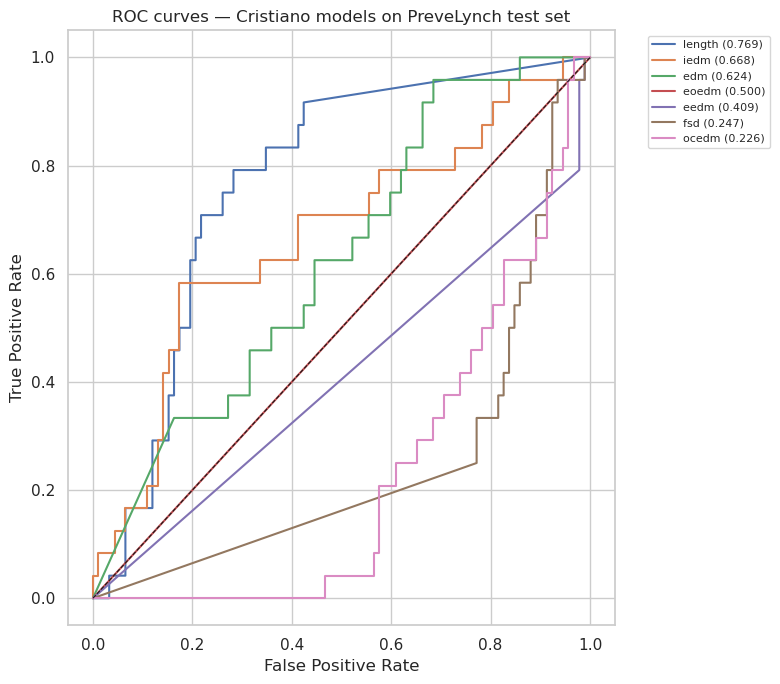

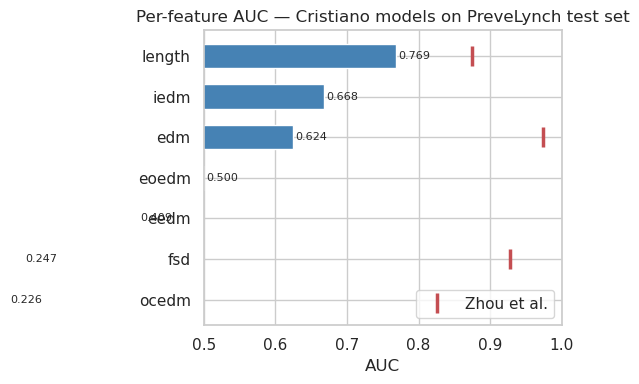

Missing: ['fsr', 'ocf', 'ifs', 'wps']


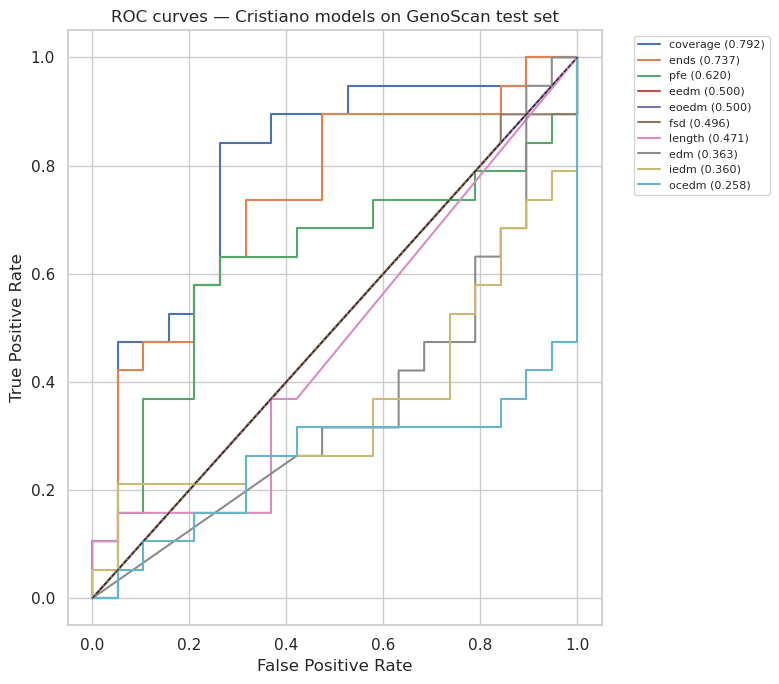

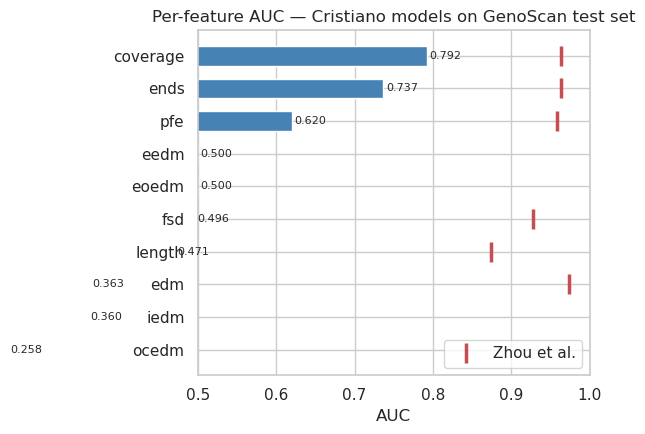

In [437]:
# Cristiano models on LY test + GS test
ly_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
gs_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"

crist_ly_roc = load_roc_data(ly_dir)
plot_roc(crist_ly_roc, 'ROC curves — Cristiano models on PreveLynch test set', 'scripts/analysis/10_roc_crist_ly.png')
plot_auc_bars(crist_ly_roc, 'Per-feature AUC — Cristiano models on PreveLynch test set', 'scripts/analysis/11_auc_crist_ly.png', zhou_ref=ZHOU_SCORES)

crist_gs_roc = load_roc_data(gs_dir)
plot_roc(crist_gs_roc, 'ROC curves — Cristiano models on GenoScan test set', 'scripts/analysis/12_roc_crist_gs.png')
plot_auc_bars(crist_gs_roc, 'Per-feature AUC — Cristiano models on GenoScan test set', 'scripts/analysis/13_auc_crist_gs.png', zhou_ref=ZHOU_SCORES)

In [438]:
# TODO: Cristiano CRC — ensemble CV
# Prerequisites: meta-matrix_crc build → ensemble CV
# Plots:
#   - ROC curve: CRC ensemble vs best CRC per-feature
#   - AUC bar: CRC ensemble vs per-feature

In [439]:
ens_df = pd.read_csv(
    "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble/cv/cv_probs.csv",
    index_col=0
)
ens_fpr, ens_tpr, _ = roc_curve(ens_df['label'], ens_df['probability'])
ens_auc = roc_auc_score(ens_df['label'], ens_df['probability'])
print(f"Ensemble AUC: {ens_auc:.4f}")

Ensemble AUC: 0.9932


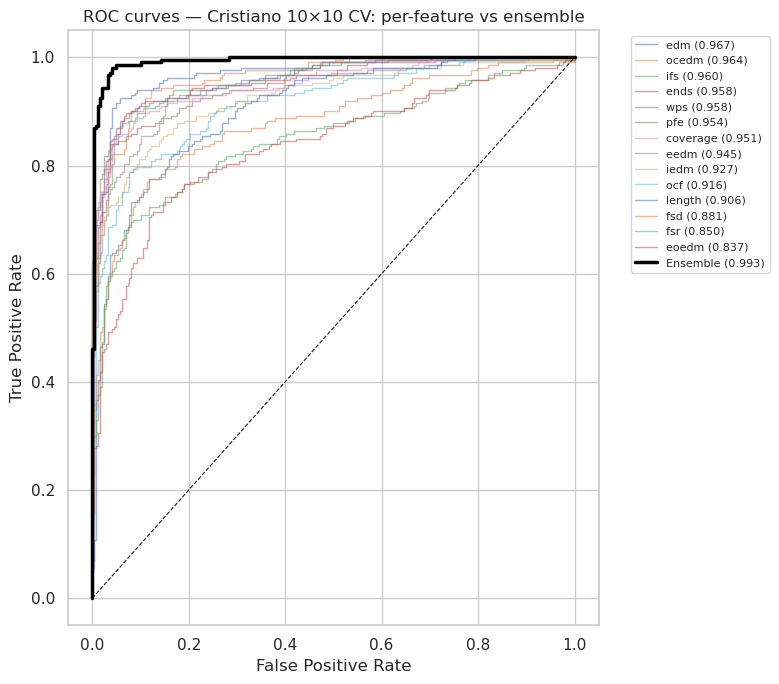

In [440]:
plt.figure(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cv_roc:
    plt.plot(d['fpr'], d['tpr'], label=f"{d['name']} ({d['auc']:.3f})", linewidth=1, alpha=0.55)
plt.plot(ens_fpr, ens_tpr, label=f"Ensemble ({ens_auc:.3f})", linewidth=2.5, color='black', zorder=5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — Cristiano 10×10 CV: per-feature vs ensemble')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/20_roc_ensemble_cv.png")

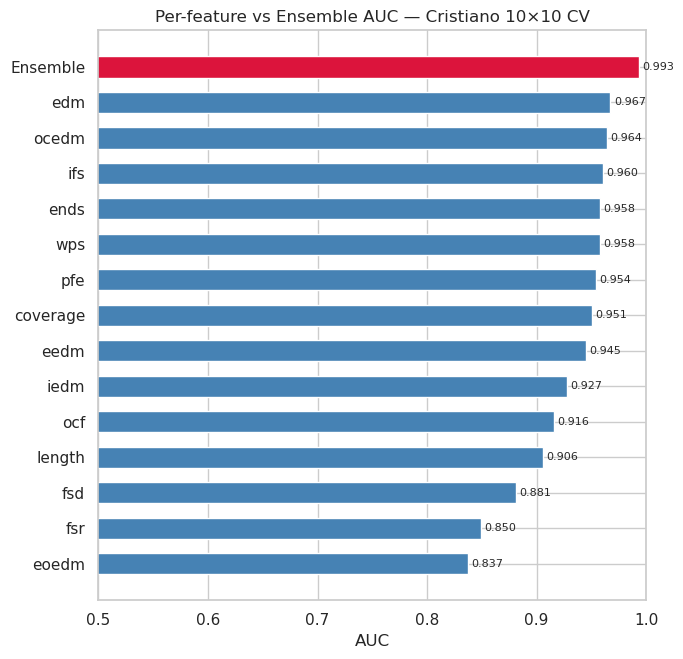

In [441]:
ens_roc_data = sorted(
    [{'name': 'Ensemble', 'fpr': ens_fpr, 'tpr': ens_tpr, 'auc': ens_auc}] + cv_roc,
    key=lambda x: x['auc'], reverse=True
)
names  = [d['name'] for d in ens_roc_data]
aucs   = [d['auc']  for d in ens_roc_data]
colors = ['crimson' if n == 'Ensemble' else 'steelblue' for n in names]

fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names)), aucs, color=colors, height=0.6)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('AUC')
ax.set_title('Per-feature vs Ensemble AUC — Cristiano 10×10 CV')
for i, auc in enumerate(aucs):
    ax.text(auc + 0.003, i, f'{auc:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/21_auc_bars_ensemble_cv.png")

In [442]:
manifest_disease = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'disease']]
ens_merge = ens_df.copy()
ens_merge.index.name = 'sample_id'
ens_merge = ens_merge.reset_index().merge(manifest_disease, on='sample_id', how='left')

healthy    = ens_merge[ens_merge['disease'] == 'Healthy']
cancer_all = ens_merge[ens_merge['label'] == 1]

EXCLUDE_TYPES = {'Duodenal cancer'}

cancer_roc_data = []

# All cancer types combined (excluding dropped types)
subset = pd.concat([cancer_all[~cancer_all['disease'].isin(EXCLUDE_TYPES)], healthy])
fpr, tpr, _ = roc_curve(subset['label'], subset['probability'])
auc = roc_auc_score(subset['label'], subset['probability'])
cancer_roc_data.append({'label': f'All cancers (n={len(subset[subset["label"]==1])})', 'fpr': fpr, 'tpr': tpr, 'auc': auc})

# Per cancer type, sorted by n descending
for ct, group in sorted(
    [(ct, g) for ct, g in cancer_all.groupby('disease') if ct not in EXCLUDE_TYPES],
    key=lambda x: -len(x[1])
):
    subset = pd.concat([group, healthy])
    fpr, tpr, _ = roc_curve(subset['label'], subset['probability'])
    auc = roc_auc_score(subset['label'], subset['probability'])
    cancer_roc_data.append({'label': f'{ct} (n={len(group)})', 'fpr': fpr, 'tpr': tpr, 'auc': auc})

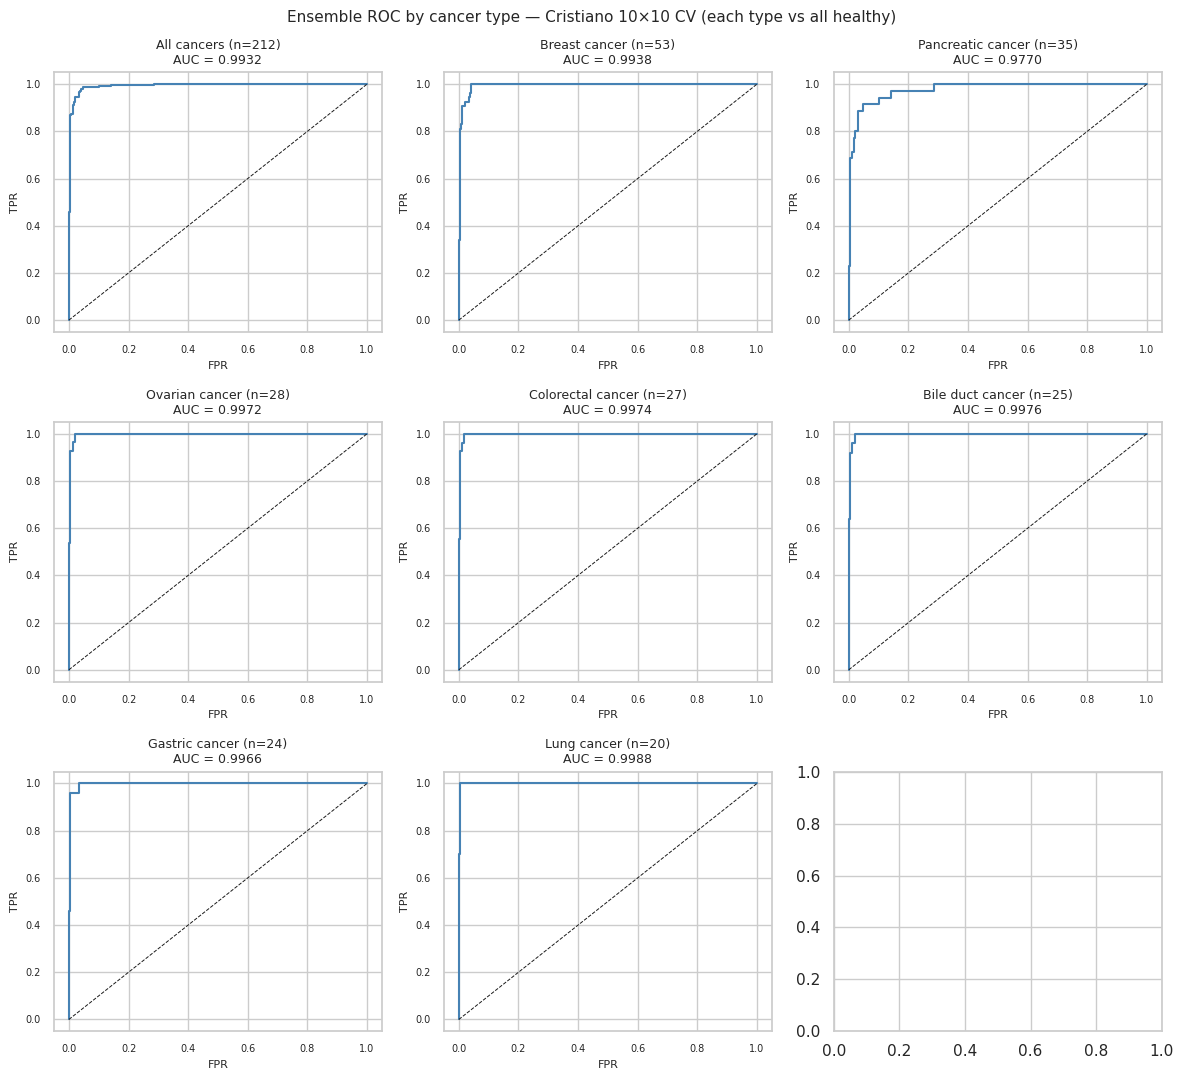

In [443]:
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
sns.set_theme(style="whitegrid")
for ax, d in zip(axes.flat, cancer_roc_data):
    ax.plot(d['fpr'], d['tpr'], color='steelblue', linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
    ax.set_title(f"{d['label']}\nAUC = {d['auc']:.4f}", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8)
    ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('Ensemble ROC by cancer type — Cristiano 10×10 CV (each type vs all healthy)', fontsize=11)
plt.tight_layout()
plt.savefig("scripts/analysis/22_roc_cancer_type_grid.png", bbox_inches='tight')

In [444]:
stage_manifest = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'stage']]
ens_stage = ens_merge.merge(stage_manifest, on='sample_id', how='left')

healthy_stage = ens_stage[ens_stage['disease'] == 'Healthy']

stage_roc_data = []
for stage in ['I', 'II', 'III', 'IV']:
    cancer_stage = ens_stage[(ens_stage['label'] == 1) & (ens_stage['stage'] == stage)]
    if len(cancer_stage) == 0:
        continue
    subset = pd.concat([cancer_stage, healthy_stage])
    fpr, tpr, _ = roc_curve(subset['label'], subset['probability'])
    auc = roc_auc_score(subset['label'], subset['probability'])
    stage_roc_data.append({'label': f'Stage {stage} (n={len(cancer_stage)})', 'fpr': fpr, 'tpr': tpr, 'auc': auc})

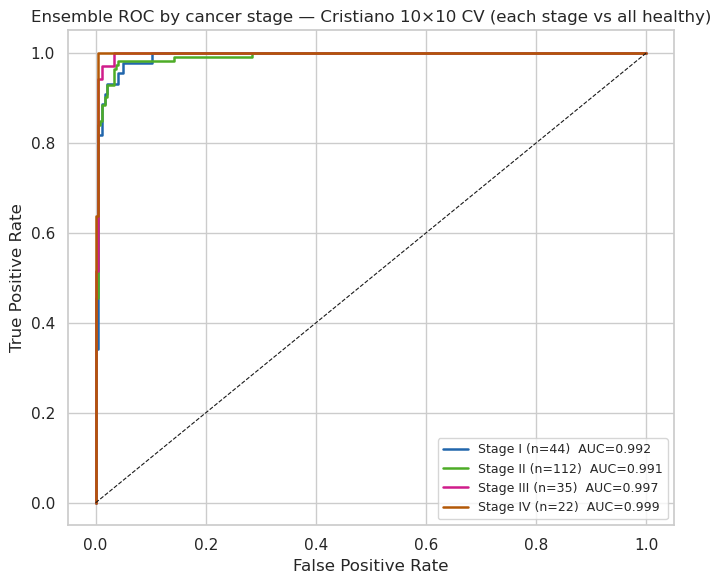

In [445]:
plt.figure(figsize=(7, 6))
sns.set_theme(style="whitegrid")
colors = ['#2166ac', '#4dac26', '#d01c8b', '#b35806']
for d, color in zip(stage_roc_data, colors):
    plt.plot(d['fpr'], d['tpr'], label=f"{d['label']}  AUC={d['auc']:.3f}", linewidth=1.8, color=color)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC by cancer stage — Cristiano 10×10 CV (each stage vs all healthy)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/23_roc_stage_ensemble.png")

In [446]:
from sklearn.metrics import roc_auc_score

cv_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
feature_names = ['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm']
manifest = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'disease', 'stage']]

records = []
for feature in feature_names:
    df = pd.read_csv(cv_dir + f"{feature}_cv_probs.csv")[['sample_id', 'probability', 'label']]
    df = df.merge(manifest, on='sample_id', how='left')
    healthy = df[df['disease'] == 'Healthy']
    for stage in ['I', 'II', 'III', 'IV']:
        cancer = df[(df['label'] == 1) & (df['stage'] == stage)]
        if len(cancer) == 0:
            continue
        subset = pd.concat([cancer, healthy])
        auc = roc_auc_score(subset['label'], subset['probability'])
        records.append({'feature': feature, 'stage': stage, 'auc': auc, 'n_cancer': len(cancer)})

stage_auc = pd.DataFrame(records)
stage_auc

,feature,stage,auc,n_cancer
0,length,I,0.888950,44
1,length,II,0.916485,112
2,length,III,0.909524,35
3,length,IV,0.882299,22
4,fsd,I,0.825480,44
5,fsd,II,0.904217,112
6,fsd,III,0.882346,35
7,fsd,IV,0.874908,22
8,fsr,I,0.770325,44
9,fsr,II,0.864983,112


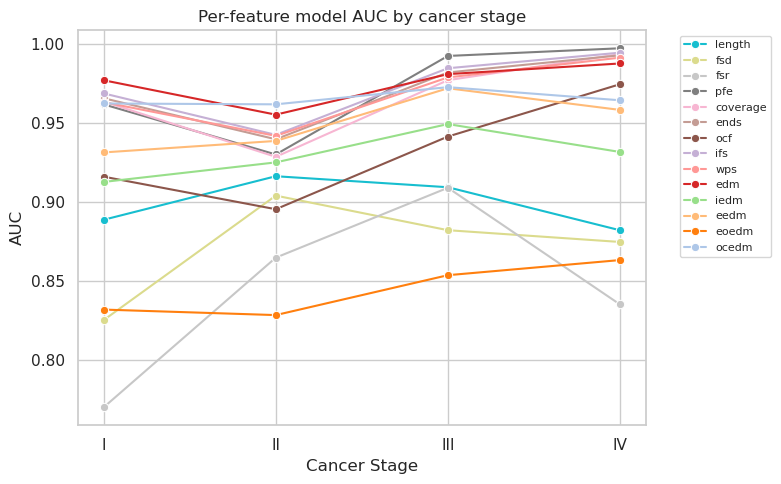

In [447]:
plot_df = stage_auc.copy()
plot_df['feature'] = plot_df['feature'].replace(RENAME)
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
# set palette to be more distinct colors for better visibility
palette = sns.color_palette("tab20_r", n_colors=plot_df['feature'].nunique())
ax = sns.lineplot(data=plot_df, x='stage', y='auc', hue='feature', marker='o', palette=palette)
ax.set_xlabel('Cancer Stage')
ax.set_ylabel('AUC')
ax.set_title('Per-feature model AUC by cancer stage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/06_stage_auc.png")

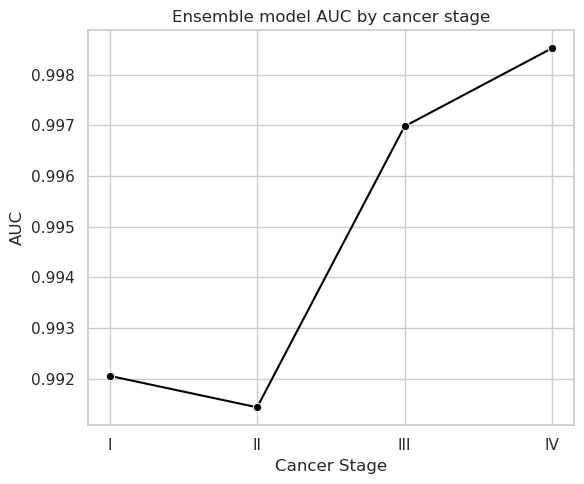

In [448]:
# same plot as above, but ensemble

ensemble_df = pd.read_csv("data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble/cv/cv_probs.csv", index_col=0)
ensemble_df.index.name = 'sample_id'
ensemble_df = ensemble_df.reset_index().merge(manifest, on='sample_id', how='left')
stage_records = []
for stage in ['I', 'II', 'III', 'IV']:
    cancer = ensemble_df[(ensemble_df['label'] == 1) & (ensemble_df['stage'] == stage)]
    if len(cancer) == 0:
        continue
    subset = pd.concat([cancer, ensemble_df[ensemble_df['disease'] == 'Healthy']])
    auc = roc_auc_score(subset['label'], subset['probability'])
    stage_records.append({'stage': stage, 'auc': auc, 'n_cancer': len(cancer)})
stage_ensemble_auc = pd.DataFrame(stage_records)
plt.figure(figsize=(6, 5))
sns.set_theme(style="whitegrid")
ax = sns.lineplot(data=stage_ensemble_auc, x='stage', y='auc', marker='o', color='black')
ax.set_xlabel('Cancer Stage')
ax.set_ylabel('AUC')
ax.set_title('Ensemble model AUC by cancer stage')
plt.tight_layout()

In [449]:
crc_cv_dir = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
crc_manifest = pd.read_csv("data/manifest/Cristiano_metadata_crc.csv")[['sample_id', 'disease', 'stage']]

crc_stage_records = []
for feature in FEATURE_NAMES:
    path = os.path.join(crc_cv_dir, f"{feature}_cv_probs.csv")
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(crc_manifest, on='sample_id', how='left')
    healthy = df[df['disease'] == 'Healthy']
    for stage in ['I', 'II', 'III', 'IV']:
        cancer = df[(df['label'] == 1) & (df['stage'] == stage)]
        if len(cancer) == 0:
            continue
        subset = pd.concat([cancer, healthy])
        auc = roc_auc_score(subset['label'], subset['probability'])
        crc_stage_records.append({'feature': feature, 'stage': stage, 'auc': auc, 'n_cancer': len(cancer)})

crc_stage_auc = pd.DataFrame(crc_stage_records)
crc_stage_auc

,feature,stage,auc,n_cancer
0,length,I,0.958188,7
1,length,II,0.976190,7
2,length,III,0.960163,5
3,length,IV,0.846037,8
4,fsd,I,0.940186,7
5,fsd,II,0.983740,7
6,fsd,III,0.950407,5
7,fsd,IV,0.954268,8
8,edm,I,0.983159,7
9,edm,II,0.995354,7


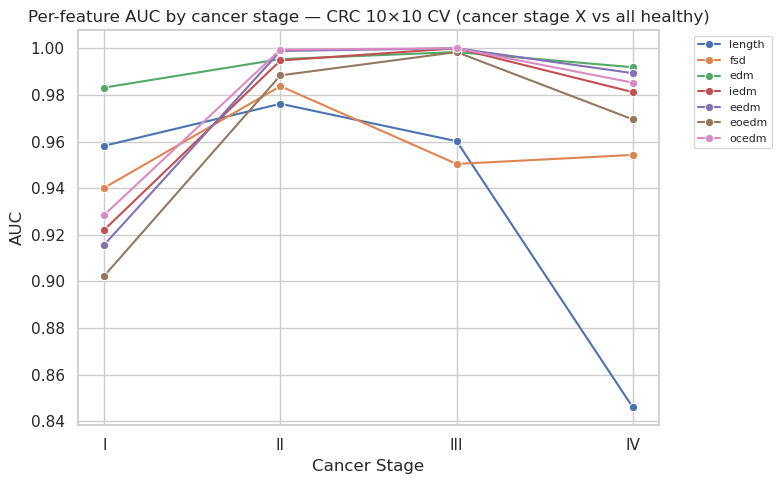

In [450]:
plot_df = crc_stage_auc.copy()
plot_df['feature'] = plot_df['feature'].replace(RENAME)
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.lineplot(data=plot_df, x='stage', y='auc', hue='feature', marker='o')
ax.set_xlabel('Cancer Stage')
ax.set_ylabel('AUC')
ax.set_title('Per-feature AUC by cancer stage — CRC 10×10 CV (cancer stage X vs all healthy)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/06b_stage_auc_crc.png")